# Lot D - Analyse Quantitative | Qualitative

### 1. Introduction et Objectifs
Dans cette section, nous procédons à l'évaluation et à l'analyse approfondie des réponses générées par notre pipeline multi-LLM. Conformément aux consignes du projet, notre objectif est de mesurer et de comparer l'impact des langues et des stratégies de prompting selon deux axes fondamentaux :<br>
* **Cultural Diversity (jeux de données `unspecific`) :** Évaluer si les réponses varient de manière cohérente et légitime lorsque la culture est implicitement inférée par la langue utilisée.
* **Cultural Robustness (jeux de données `specific`) :** Vérifier la stabilité et la convergence des réponses entre les différentes langues lorsque le contexte géographique ou culturel est explicitement fixé dans le prompt.

Pour y parvenir, nous croisons des métriques statistiques rigoureuses avec une étude critique des contenus générés.<br><br>

### 2. Approche Quantitative : Métriques et Structuration Données
L'analyse quantitative vise à extraire des descripteurs numériques objectifs pour comparer la baseline et nos trois variantes (`cot_cultural`, `system_constrained`, `rewritten_query`).<br>
* **Statistiques descriptives de base :** Analyse de la distribution des longueurs de réponses (nombre de tokens/mots) et calcul du taux de réponses vides ou d'échecs (timeout/quota) pour évaluer la robustesse opérationnelle des providers.
* **Analyse sémantique par Embeddings :** Extraction des représentations vectorielles (via des embeddings BERT, complétés par une approche Word2Vec pour comparaison). Calcul de la similarité cosinus inter-langues pour quantifier précisément la cohérence sémantique (`specific`) ou la divergence sémantique (`unspecific`).
* **Clustering et Réduction de Dimension :** Application de l'algorithme *K-Means* (ou clustering basé sur la distance cosinus) sur les embeddings pour partitionner mathématiquement l'espace des réponses. Projection visuelle en 2D via l'algorithme *t-SNE* afin d'observer statistiquement si les réponses se regroupent par langue, par variante de prompt ou par type de dataset.<br><br>

### 3. Approche Qualitative : Interprétation et Typologie des Écarts
L'analyse qualitative donne du sens aux chiffres en interrogeant directement la pertinence culturelle et le respect des consignes.<br>
* **Analyse et interprétation des Clusters :** Exploration humaine des partitions identifiées par le K-Means. Qu'est-ce qui unit les réponses d'un même cluster ? Observe-t-on des biais ou des structures linguistiques récurrentes ?
* **Étude comparative Baseline vs Variantes :** Évaluation de l'impact concret du Prompt Engineering. Les stratégies avancées (ex: reformulation ou contrainte de style) permettent-elles de lisser les hallucinations ou, au contraire, brident-elles la diversité culturelle attendue ?
* **Typologie des erreurs et des écarts :** Sélection de cas d'étude représentatifs (exemples à forte ou faible variabilité, réponses anormalement longues) pour isoler et catégoriser les phénomènes observés : *généricité excessive, stéréotypes culturels, hallucinations géographiques*, ou *non-respect des contraintes de format* (ex: consigne d'une seule phrase non respectée).

## Installation des dépendances

In [15]:
pip install sentence-transformers pandas matplotlib seaborn scikit-learn gensim nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.6 MB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Chargement des données

In [1]:
import pandas as pd
import os

data_dir = 'data/'
loaded_data = {}

for filename in os.listdir(data_dir):
    if filename.endswith('.jsonl') and not filename.startswith('submission'):
        filepath = os.path.join(data_dir, filename)
        key = filename.replace('.jsonl', '')
        try:
            df = pd.read_json(filepath, lines=True)
            loaded_data[key] = df
            print(f"Fichier {filename} chargé avec {len(df)} lignes.")
        except Exception as e:
            print(f"Erreur d'extraction de {filename}: {e}")

In [25]:
import pandas as pd
# Construire combined_df si absent
if 'combined_df' not in globals():
    frames = []
    for name, df in loaded_data.items():
        df2 = df.copy()
        df2['dataset_name'] = name
        # Détecter la colonne de prompt
        if 'prompt' in df2.columns:
            prompt_col = 'prompt'
        else:
            cand = [c for c in df2.columns if any(k in c.lower() for k in ['prompt','question','input','query','instruction'])]
            prompt_col = cand[0] if cand else None
        if prompt_col:
            df2['prompt_word_count'] = df2[prompt_col].fillna('').astype(str).apply(lambda s: len(s.split()))
        else:
            df2['prompt_word_count'] = 0
        frames.append(df2)
    if frames:
        combined_df = pd.concat(frames, ignore_index=True)
    else:
        combined_df = pd.DataFrame()
# Extraire langue et spécificité
combined_df['language'] = combined_df['dataset_name'].apply(lambda x: x.split('_')[0] if isinstance(x, str) else '')
combined_df['specificity'] = combined_df['dataset_name'].apply(lambda x: x.split('_')[1] if isinstance(x, str) and len(x.split('_'))>1 else '')
stats_dataset = combined_df.groupby('dataset_name')['prompt_word_count'].agg(['mean','var','count']).rename(columns={'mean':'moyenne','var':'variance','count':'n'})
display(stats_dataset.sort_values('moyenne', ascending=False))

,moyenne,variance,n
dataset_name,,,
fr_specific,46.665205,44.888995,8208
de_specific,41.914493,43.223029,8280
en_specific,41.476087,42.819334,8280
es_specific,40.500483,37.049160,8280
ru_specific,33.223671,36.903220,8280
fr_unspecific,21.811881,53.909933,404
de_unspecific,20.138614,49.410019,404
en_unspecific,19.423567,48.328005,314
es_unspecific,19.415842,42.188930,404


## Distribution des données d'entrées

Loading and preparing data for distribution analysis...
Prepared de_specific.jsonl with 4140 lines.
Prepared en_specific.jsonl with 4140 lines.
Prepared es_specific.jsonl with 4140 lines.
Prepared fr_specific.jsonl with 4104 lines.
Prepared ru_specific.jsonl with 4140 lines.
Prepared de_specific.jsonl with 4140 lines.
Prepared en_specific.jsonl with 4140 lines.
Prepared es_specific.jsonl with 4140 lines.
Prepared fr_specific.jsonl with 4104 lines.
Prepared ru_specific.jsonl with 4140 lines.
Prepared de_unspecific.jsonl with 101 lines.
Prepared en_unspecific.jsonl with 101 lines.
Prepared es_unspecific.jsonl with 101 lines.
Prepared fr_unspecific.jsonl with 101 lines.
Prepared ru_unspecific.jsonl with 101 lines.
Prepared de_unspecific.jsonl with 101 lines.
Prepared en_unspecific.jsonl with 101 lines.
Prepared es_unspecific.jsonl with 101 lines.
Prepared fr_unspecific.jsonl with 101 lines.
Prepared ru_unspecific.jsonl with 101 lines.
Prepared de_unspecific.jsonl with 101 lines.
Prepared 

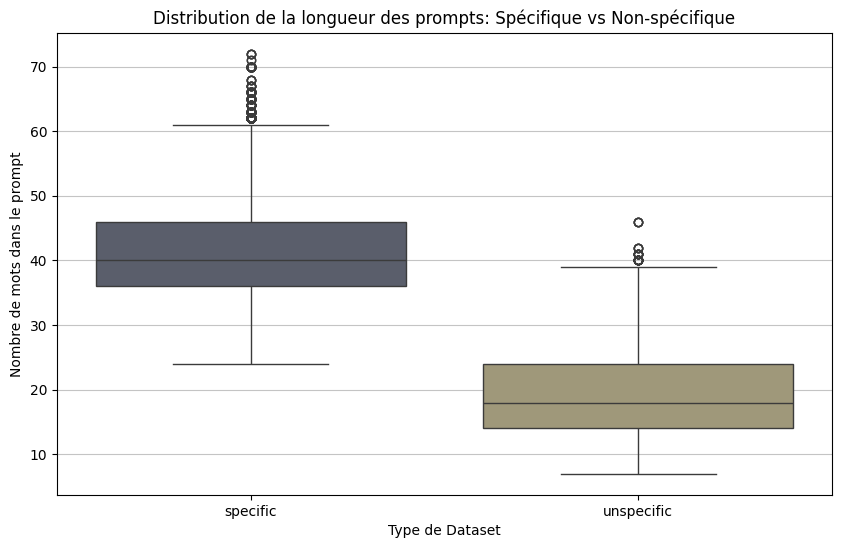

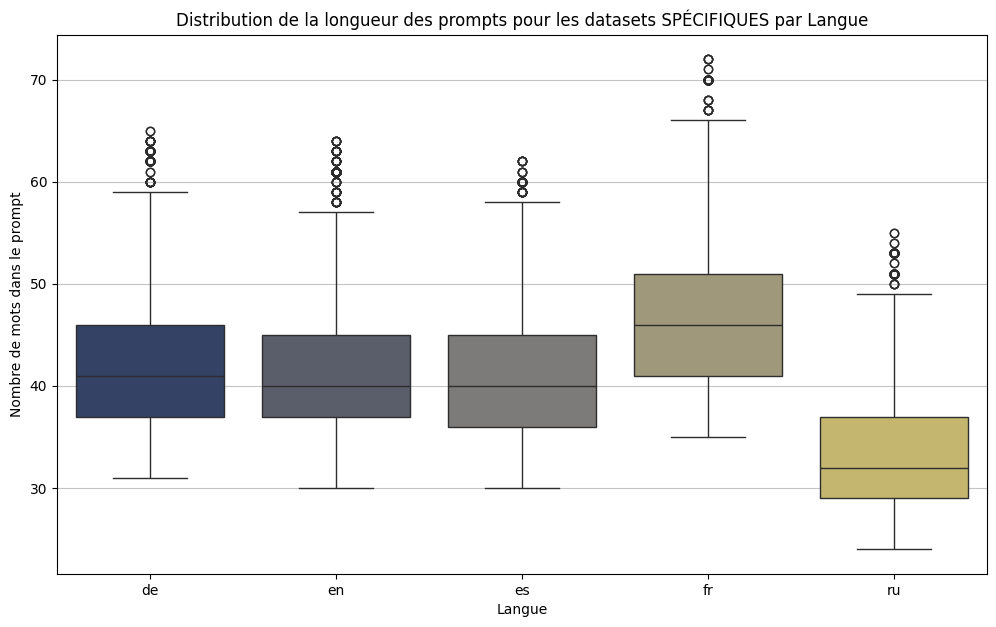

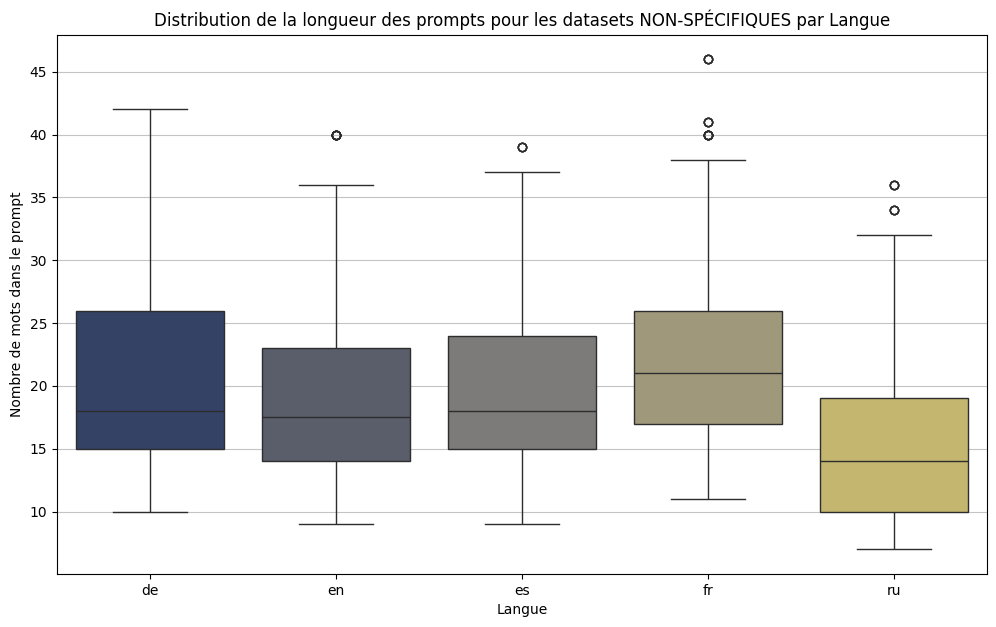

In [ ]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# --- Start of added/modified code to define combined_df ---
data_dir = 'data/'
all_dfs = []

print("Loading and preparing data for distribution analysis...")
for root, dirs, files in os.walk(data_dir):
    for filename in files:
        # Ensure we only process relevant jsonl files and exclude submission metadata
        if filename.endswith('.jsonl') and not filename.startswith('submission_metadata'):
            filepath = os.path.join(root, filename)
            # The filename typically contains 'language_specificity' (e.g., 'ru_unspecific.jsonl')
            dataset_name_from_file = filename.replace('.jsonl', '')

            try:
                df = pd.read_json(filepath, lines=True)
                df['dataset_name'] = dataset_name_from_file
                # Assuming 'prompt' column exists in these jsonl files for word count
                if 'prompt' in df.columns:
                    df['prompt_word_count'] = df['prompt'].apply(lambda x: len(str(x).split()))
                else:
                    print(f"Warning: 'prompt' column not found in {filename}. 'prompt_word_count' will not be calculated for this file.")
                    df['prompt_word_count'] = 0 # Assign a default or handle as needed

                all_dfs.append(df)
                print(f"Prepared {filename} with {len(df)} lines.")
            except KeyError as e:
                print(f"Error: Column '{e}' not found in {filename}. Skipping this file.")
            except Exception as e:
                print(f"Error processing {filename}: {e}. Skipping this file.")

if all_dfs:
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f"Combined data into combined_df with {len(combined_df)} rows.")
else:
    print("No valid data files found or processed to create combined_df. Creating an empty DataFrame.")
    combined_df = pd.DataFrame(columns=['dataset_name', 'prompt', 'prompt_word_count', 'language', 'specificity'])
# --- End of added/modified code ---

combined_df['language'] = combined_df['dataset_name'].apply(lambda x: x.split('_')[0])
combined_df['specificity'] = combined_df['dataset_name'].apply(lambda x: x.split('_')[1])

plt.figure(figsize=(10, 6))
sns.boxplot(x='specificity', y='prompt_word_count', hue='specificity', data=combined_df, palette='cividis', legend=False)
plt.title('Distribution de la longueur des prompts: Spécifique vs Non-spécifique')
plt.xlabel('Type de Dataset')
plt.ylabel('Nombre de mots dans le prompt')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\n")
print("\n")

plt.figure(figsize=(12, 7))
sns.boxplot(x='language', y='prompt_word_count', hue='language', data=combined_df[combined_df['specificity'] == 'specific'], palette='cividis', legend=False)
plt.title('Distribution de la longueur des prompts pour les datasets SPÉCIFIQUES par Langue')
plt.xlabel('Langue')
plt.ylabel('Nombre de mots dans le prompt')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\n")
print("\n")

plt.figure(figsize=(12, 7))
sns.boxplot(x='language', y='prompt_word_count', hue='language', data=combined_df[combined_df['specificity'] == 'unspecific'], palette='cividis', legend=False)
plt.title('Distribution de la longueur des prompts pour les datasets NON-SPÉCIFIQUES par Langue')
plt.xlabel('Langue')
plt.ylabel('Nombre de mots dans le prompt')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Analyse quantitative

### Chargement des données de soumission

In [3]:
import pandas as pd
import os

submission_dir = 'data/'
submission_data = {}

print("Chargement des fichiers de soumission...")
for root, dirs, files in os.walk(submission_dir):
    for filename in files:
        if filename.endswith('.jsonl') and not filename.startswith('submission_metadata'):
            filepath = os.path.join(root, filename)

            # Extract variant, specificity, and language from the path
            path_parts = filepath.split(os.sep)

            # Assuming structure: /content/data/<specificity_type>/<variant>/<lang_specificity_filename>.jsonl
            # specificity_type will be at index -3
            # variant will be at index -2

            # Determine specificity and variant from the path
            current_specificity = path_parts[-3] # 'unspecific' or 'specific'
            current_variant = path_parts[-2] # 'baseline', 'cot_cultural', 'rewritten_query'

            # Extract language and specificity from filename
            filename_parts = filename.replace('.jsonl', '').split('_')
            language = filename_parts[0]

            # Create a unique key for the dictionary: variant_specificity_language
            key = f"{current_variant}_{current_specificity}_{language}"

            try:
                df_submission = pd.read_json(filepath, lines=True)
                submission_data[key] = df_submission
                print(f"Fichier {filename} ({key}) chargé avec {len(df_submission)} lignes.")
            except Exception as e:
                print(f"Erreur de chargement de {filename} ({key}): {e}")

Chargement des fichiers de soumission...
Fichier de_specific.jsonl (baseline_data/specific_de) chargé avec 4140 lignes.
Fichier en_specific.jsonl (baseline_data/specific_en) chargé avec 4140 lignes.
Fichier es_specific.jsonl (baseline_data/specific_es) chargé avec 4140 lignes.
Fichier fr_specific.jsonl (baseline_data/specific_fr) chargé avec 4104 lignes.
Fichier ru_specific.jsonl (baseline_data/specific_ru) chargé avec 4140 lignes.
Fichier de_specific.jsonl (rewritten_query_data/specific_de) chargé avec 4140 lignes.
Fichier en_specific.jsonl (rewritten_query_data/specific_en) chargé avec 4140 lignes.
Fichier es_specific.jsonl (rewritten_query_data/specific_es) chargé avec 4140 lignes.
Fichier fr_specific.jsonl (rewritten_query_data/specific_fr) chargé avec 4104 lignes.
Fichier ru_specific.jsonl (rewritten_query_data/specific_ru) chargé avec 4140 lignes.
Fichier de_unspecific.jsonl (baseline_data/unspecific_de) chargé avec 101 lignes.
Fichier en_unspecific.jsonl (baseline_data/unspecifi

## Robustesse des providers

In [4]:
print("\nAnalyse de la robustesse des providers (longueur des réponses et réponses vides):\n")

robustness_stats = []

for dataset_name, df_sub in submission_data.items():
    response_col_name = None
    if 'answer' in df_sub.columns:
        response_col_name = 'answer'
    else:
        # Attempt to infer the response column
        # Assuming the response column is the one that's not 'id' or 'prompt'
        other_cols = [col for col in df_sub.columns if col not in ['id', 'prompt']]
        if len(other_cols) == 1:
            response_col_name = other_cols[0]
            print(f"Inférence: La colonne de réponse pour {dataset_name} est '{response_col_name}'.")
        elif len(other_cols) > 1:
            print(f"Avertissement: Plusieurs colonnes potentielles de réponse trouvées pour {dataset_name}: {other_cols}. Utilisation de la première '{other_cols[0]}'.")
            response_col_name = other_cols[0]
        else:
            print(f"Avertissement: Impossible d'inférer la colonne de réponse pour {dataset_name}. Colonnes disponibles: {df_sub.columns.tolist()}")

    if response_col_name:
        df_sub['response_word_count'] = df_sub[response_col_name].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
        df_sub['is_empty_response'] = df_sub[response_col_name].apply(lambda x: pd.isna(x) or str(x).strip() == '')

        total_responses = len(df_sub)
        empty_responses = df_sub['is_empty_response'].sum()
        empty_response_percentage = (empty_responses / total_responses * 100) if total_responses > 0 else 0

        robustness_stats.append({
            'Dataset': dataset_name,
            'Nombre total de réponses': total_responses,
            'Nombre de réponses vides': empty_responses,
            '% de réponses vides': f"{empty_response_percentage:.2f}%",
            'Longueur moyenne des réponses (mots)': df_sub['response_word_count'].mean(),
            'Longueur médiane des réponses (mots)': df_sub['response_word_count'].median(),
            'Longueur minimale des réponses (mots)': df_sub['response_word_count'].min(),
            'Longueur maximale des réponses (mots)': df_sub['response_word_count'].max()
        })
    else:
        print(f"Analyse ignorée pour {dataset_name} en raison de l'absence de colonne de réponse.")

if robustness_stats:
    robustness_df = pd.DataFrame(robustness_stats)
    display(robustness_df)
else:
    print("Aucune donnée de soumission valide trouvée pour l'analyse de robustesse après inférence.")


Analyse de la robustesse des providers (longueur des réponses et réponses vides):



,Dataset,Nombre total de réponses,Nombre de réponses vides,% de réponses vides,Longueur moyenne des réponses (mots),Longueur médiane des réponses (mots),Longueur minimale des réponses (mots),Longueur maximale des réponses (mots)
0,baseline_data/specific_de,4140,0,0.00%,36.086473,36.0,2,115
1,baseline_data/specific_en,4140,0,0.00%,30.865217,30.0,7,58
2,baseline_data/specific_es,4140,0,0.00%,34.415700,34.0,13,133
3,baseline_data/specific_fr,4104,0,0.00%,33.564327,32.0,11,160
4,baseline_data/specific_ru,4140,0,0.00%,25.634783,25.0,2,52
5,rewritten_query_data/specific_de,4140,0,0.00%,23.489855,24.0,4,47
6,rewritten_query_data/specific_en,4140,0,0.00%,27.011836,28.0,1,55
7,rewritten_query_data/specific_es,4140,0,0.00%,25.693237,25.0,10,99
8,rewritten_query_data/specific_fr,4104,0,0.00%,24.505117,24.0,5,133
9,rewritten_query_data/specific_ru,4140,0,0.00%,19.577053,19.0,3,40


## Analyse sémantique embeddings

### Génération embeddings BERT

In [5]:
from sentence_transformers import SentenceTransformer

# Charger un modèle BERT multilingue pré-entraîné
# 'paraphrase-multilingual-MiniLM-L12-v2' est un bon choix pour l'efficacité et la performance multilingue.
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

# Dictionnaire pour stocker les embeddings BERT pour chaque dataset de soumission
submission_embeddings_bert = {}

for dataset_name, df_sub in submission_data.items():
    # Assurez-vous que la colonne 'answer' existe, sinon utilisez la colonne inférée comme précédemment
    response_col_name = 'answer'
    if response_col_name not in df_sub.columns:
        # Tentative d'inférence de la colonne de réponse si 'answer' n'est pas présente
        other_cols = [col for col in df_sub.columns if col not in ['id', 'prompt']]
        if len(other_cols) == 1:
            response_col_name = other_cols[0]
        elif len(other_cols) > 1:
            response_col_name = other_cols[0] # Prendre la première comme fallback
        else:
            print(f"Avertissement: Impossible d'identifier la colonne de réponse pour {dataset_name}. Ignoré.")
            continue

    # Extraire les réponses, en s'assurant qu'elles sont des chaînes de caractères et non vides
    responses = df_sub[response_col_name].fillna('').astype(str).tolist()

    # Générer les embeddings pour toutes les réponses du dataset
    embeddings = model.encode(responses, show_progress_bar=True)
    submission_embeddings_bert[dataset_name] = embeddings

print("\nEmbeddings BERT pour tous les datasets de soumission générés.")
# Vous pouvez maintenant accéder aux embeddings pour un dataset spécifique comme :
# bert_embeddings_ru_unspecific = submission_embeddings_bert['ru_unspecific']

c:\Users\HugoDarthenay-Kienne\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 4/4 [00:02<00:00,  1.92it/s]


Embeddings BERT pour tous les datasets de soumission générés.


### Calcul de la Similarité Cosinus Inter-langues (BERT) - Jeu de données specific

In [6]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_inter_language_similarity(embeddings_dict, embedding_type='BERT'):
    # This structure will be {variant: {specificity: {language: mean_embedding}}}
    variant_specificity_language_embeddings = {}

    for dataset_name, embeddings in embeddings_dict.items():
        name_parts = dataset_name.split('_')

        if len(name_parts) < 2:
            print(f"Avertissement: Nom de dataset inattendu (moins de 2 parties): {dataset_name}. Ignoré.")
            continue

        language = name_parts[-1]
        specificity = name_parts[-2]

        # Reconstruct variant from all parts before specificity and language
        variant_parts = name_parts[:-2]
        if not variant_parts:
            variant = 'unknown_variant'
        else:
            variant = '_'.join(variant_parts)

        # Process ONLY 'specific' data as requested
        if specificity != 'specific':
            continue

        # Initialize structure if variant is new
        if variant not in variant_specificity_language_embeddings:
            variant_specificity_language_embeddings[variant] = {'specific': {}}

        variant_specificity_language_embeddings[variant]['specific'][language] = np.mean(embeddings, axis=0)

    for variant, specificity_data in variant_specificity_language_embeddings.items():
        if 'specific' in specificity_data:
            lang_embeddings = specificity_data['specific']
            if not lang_embeddings:
                continue
            languages = sorted(list(lang_embeddings.keys()))
            similarity_matrix = pd.DataFrame(index=languages, columns=languages, dtype=float)

            for i in range(len(languages)):
                for j in range(i, len(languages)):
                    lang1 = languages[i]
                    lang2 = languages[j]

                    emb1 = lang_embeddings.get(lang1)
                    emb2 = lang_embeddings.get(lang2)

                    if emb1 is not None and emb2 is not None:
                        similarity = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))[0][0]
                        similarity_matrix.loc[lang1, lang2] = similarity
                        similarity_matrix.loc[lang2, lang1] = similarity

            plt.figure(figsize=(8, 6))
            sns.heatmap(similarity_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
            plt.title(f'Similarité Cosinus Inter-langues pour {embedding_type} (Specific - Variant: {variant})')
            plt.show()

            print("\n")
            print("\n")
    global_specific_lang_embeddings = {}
    for variant, specificity_data in variant_specificity_language_embeddings.items():
        if 'specific' in specificity_data:
            for language, embedding in specificity_data['specific'].items():
                if language not in global_specific_lang_embeddings:
                    global_specific_lang_embeddings[language] = []
                global_specific_lang_embeddings[language].append(embedding)

    for language, embeddings_list in global_specific_lang_embeddings.items():
        global_specific_lang_embeddings[language] = np.mean(embeddings_list, axis=0)

    if global_specific_lang_embeddings:
        languages = sorted(list(global_specific_lang_embeddings.keys()))
        global_similarity_matrix = pd.DataFrame(index=languages, columns=languages, dtype=float)

        for i in range(len(languages)):
            for j in range(i, len(languages)):
                lang1 = languages[i]
                lang2 = languages[j]

                emb1 = global_specific_lang_embeddings.get(lang1)
                emb2 = global_specific_lang_embeddings.get(lang2)

                if emb1 is not None and emb2 is not None:
                    similarity = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))[0][0]
                    global_similarity_matrix.loc[lang1, lang2] = similarity
                    global_similarity_matrix.loc[lang2, lang1] = similarity

        plt.figure(figsize=(8, 6))
        sns.heatmap(global_similarity_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
        plt.title(f'Similarité Cosinus Inter-langues pour {embedding_type} (Specific - Global)')
        print("\n")
        plt.show()

        print("\n")
        print("\n")
    else:
        print("Aucune donnée 'specific' suffisante trouvée pour l'analyse globale.")

    print("Analyse de similarité terminée, uniquement pour les données 'specific'.")

calculate_inter_language_similarity(submission_embeddings_bert, 'BERT')

Aucune donnée 'specific' suffisante trouvée pour l'analyse globale.
Analyse de similarité terminée, uniquement pour les données 'specific'.


### Calcul de la Similarité Cosinus Inter-langues (BERT) - Jeu de données unspecific

In [7]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_inter_language_similarity(embeddings_dict, embedding_type='BERT'):
    # This structure will be {variant: {specificity: {language: mean_embedding}}}
    variant_specificity_language_embeddings = {}

    for dataset_name, embeddings in embeddings_dict.items():
        name_parts = dataset_name.split('_')

        if len(name_parts) < 2:
            print(f"Avertissement: Nom de dataset inattendu (moins de 2 parties): {dataset_name}. Ignoré.")
            continue

        language = name_parts[-1]
        specificity = name_parts[-2]

        # Reconstruct variant from all parts before specificity and language
        variant_parts = name_parts[:-2]
        if not variant_parts:
            variant = 'unknown_variant'
        else:
            variant = '_'.join(variant_parts)

        # Process ONLY 'unspecific' data as requested
        if specificity != 'unspecific':
            continue

        # Initialize structure if variant is new
        if variant not in variant_specificity_language_embeddings:
            variant_specificity_language_embeddings[variant] = {'unspecific': {}}

        variant_specificity_language_embeddings[variant]['unspecific'][language] = np.mean(embeddings, axis=0)

    # --- First part: Per-variant Inter-language similarity (heatmaps for each unspecific variant) ---
    print(f"--- Similarité Cosinus Inter-langues (Unspecific, par Variant) pour {embedding_type} ---")
    for variant, specificity_data in variant_specificity_language_embeddings.items():
        if 'unspecific' in specificity_data:
            lang_embeddings = specificity_data['unspecific']
            if not lang_embeddings:
                continue
            languages = sorted(list(lang_embeddings.keys()))
            similarity_matrix = pd.DataFrame(index=languages, columns=languages, dtype=float)

            for i in range(len(languages)):
                for j in range(i, len(languages)):
                    lang1 = languages[i]
                    lang2 = languages[j]

                    emb1 = lang_embeddings.get(lang1)
                    emb2 = lang_embeddings.get(lang2)

                    if emb1 is not None and emb2 is not None:
                        similarity = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))[0][0]
                        similarity_matrix.loc[lang1, lang2] = similarity
                        similarity_matrix.loc[lang2, lang1] = similarity

            plt.figure(figsize=(8, 6))
            sns.heatmap(similarity_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
            plt.title(f'Similarité Cosinus Inter-langues pour {embedding_type} (Unspecific - Variant: {variant})')
            plt.show()

            print("\n")
            print("\n")

    # --- Second part: Global Unspecific Inter-language similarity (aggregated across all unspecific variants) ---
    print(f"--- Similarité Cosinus Inter-langues (Unspecific - Global) pour {embedding_type} ---")
    global_unspecific_lang_embeddings = {}

    # Aggregate embeddings for each language across all unspecific variants
    for variant, specificity_data in variant_specificity_language_embeddings.items():
        if 'unspecific' in specificity_data:
            for language, embedding in specificity_data['unspecific'].items():
                if language not in global_unspecific_lang_embeddings:
                    global_unspecific_lang_embeddings[language] = []
                global_unspecific_lang_embeddings[language].append(embedding)

    # Calculate mean embedding for each language for the global unspecific view
    for language, embeddings_list in global_unspecific_lang_embeddings.items():
        global_unspecific_lang_embeddings[language] = np.mean(embeddings_list, axis=0)

    if global_unspecific_lang_embeddings:
        languages = sorted(list(global_unspecific_lang_embeddings.keys()))
        global_similarity_matrix = pd.DataFrame(index=languages, columns=languages, dtype=float)

        for i in range(len(languages)):
            for j in range(i, len(languages)):
                lang1 = languages[i]
                lang2 = languages[j]

                emb1 = global_unspecific_lang_embeddings.get(lang1)
                emb2 = global_unspecific_lang_embeddings.get(lang2)

                if emb1 is not None and emb2 is not None:
                    similarity = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))[0][0]
                    global_similarity_matrix.loc[lang1, lang2] = similarity
                    global_similarity_matrix.loc[lang2, lang1] = similarity

        plt.figure(figsize=(8, 6))
        sns.heatmap(global_similarity_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
        plt.title(f'Similarité Cosinus Inter-langues pour {embedding_type} (Unspecific - Global)')
        print("\n")
        plt.show()

        print("\n")
        print("\n")
    else:
        print("Aucune donnée 'unspecific' suffisante trouvée pour l'analyse globale.")

    print("Analyse de similarité terminée, uniquement pour les données 'unspecific'.")

calculate_inter_language_similarity(submission_embeddings_bert, 'BERT')

--- Similarité Cosinus Inter-langues (Unspecific, par Variant) pour BERT ---
--- Similarité Cosinus Inter-langues (Unspecific - Global) pour BERT ---
Aucune donnée 'unspecific' suffisante trouvée pour l'analyse globale.
Analyse de similarité terminée, uniquement pour les données 'unspecific'.


### Visualisation des Clusters BERT (t-SNE)

In [9]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# Prepare data for t-SNE and clustering
all_bert_embeddings = []
bert_dataset_names = []

for dataset_name, embeddings in submission_embeddings_bert.items():
    all_bert_embeddings.append(embeddings)
    # Each embedding corresponds to a response, so we need to repeat the dataset name
    # for each response in that dataset.
    bert_dataset_names.extend([dataset_name] * len(embeddings))

# Concatenate all embeddings into a single numpy array
all_bert_embeddings = np.vstack(all_bert_embeddings)

# Define number of clusters for K-Means (can be adjusted)
num_clusters_bert = 5

kmeans_bert = KMeans(n_clusters=num_clusters_bert, random_state=42, n_init=10)
cluster_labels_bert = kmeans_bert.fit_predict(all_bert_embeddings)

# 1. Perform t-SNE Dimensionality Reduction to create tsne_df_bert
# Re-running t-SNE is necessary if tsne_df_bert was not created or was lost.
# Using fixed parameters for reproducibility.
tsne_bert = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results_bert = tsne_bert.fit_transform(all_bert_embeddings)

# 2. Create DataFrame for t-SNE results
tsne_df_bert = pd.DataFrame(tsne_results_bert, columns=['tsne-2d-one', 'tsne-2d-two'])
tsne_df_bert['cluster'] = cluster_labels_bert
tsne_df_bert['dataset'] = bert_dataset_names

# 3. Adapt dataset parsing to the new naming convention (variant_specificity_language)
# Example: "baseline_unspecific_ru"
tsne_df_bert['language'] = tsne_df_bert['dataset'].apply(lambda x: x.split('_')[-1]) # 'ru'
tsne_df_bert['specificity'] = tsne_df_bert['dataset'].apply(lambda x: x.split('_')[-2]) # 'unspecific'
tsne_df_bert['variant'] = tsne_df_bert['dataset'].apply(lambda x: '_'.join(x.split('_')[:-2])) # 'baseline'

print(tsne_df_bert.head())

   tsne-2d-one  tsne-2d-two  cluster                    dataset language  \
0    35.659348     1.288960        0  baseline_data/specific_de       de   
1    36.630993    -0.559965        0  baseline_data/specific_de       de   
2    29.807949    -2.117680        0  baseline_data/specific_de       de   
3    27.809982    -3.545986        0  baseline_data/specific_de       de   
4    34.333218    -2.979994        0  baseline_data/specific_de       de   

     specificity   variant  
0  data/specific  baseline  
1  data/specific  baseline  
2  data/specific  baseline  
3  data/specific  baseline  
4  data/specific  baseline  


In [10]:
# The list of analysis criteria requested for 'specific' data
criteres_analyse_specific = ["cluster", "language", "variant"]

# Filter tsne_df_bert for 'specific' data only
tsne_df_bert_specific = tsne_df_bert[tsne_df_bert['specificity'] == 'specific'].copy()

print("Visualisation t-SNE pour les données BERT SPÉCIFIQUES:")

# Loop over each criterion to generate the corresponding plots for specific data
for critere in criteres_analyse_specific:
    # Check if the column exists in the DataFrame to avoid errors
    if critere in tsne_df_bert_specific.columns and not tsne_df_bert_specific[critere].empty:
        plt.figure(figsize=(12, 10))

        # t-SNE remains the same (x and y), only the color (hue) changes!
        sns.scatterplot(
            x="tsne-2d-one",
            y="tsne-2d-two",
            hue=critere,
            palette=sns.color_palette("hls", len(tsne_df_bert_specific[critere].unique())),
            data=tsne_df_bert_specific,
            legend="full",
            alpha=0.7,
            s=50 # Adjust point size for better visibility
        )

        # Dynamic title to indicate what is being viewed
        plt.title(f'Visualisation t-SNE BERT SPÉCIFIQUE - Coloration par : {critere}')
        plt.xlabel('t-SNE Dimension 1')
        plt.ylabel('t-SNE Dimension 2')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout() # Adjust layout to prevent labels overlapping
        plt.show()
        print("\n") # Add a newline for better separation between plots
    else:
        print(f"Attention : La colonne '{critere}' ou ses données sont absentes/vides pour les données spécifiques.")

Visualisation t-SNE pour les données BERT SPÉCIFIQUES:
Attention : La colonne 'cluster' ou ses données sont absentes/vides pour les données spécifiques.
Attention : La colonne 'language' ou ses données sont absentes/vides pour les données spécifiques.
Attention : La colonne 'variant' ou ses données sont absentes/vides pour les données spécifiques.


In [11]:
# The list of analysis criteria requested for 'unspecific' data
criteres_analyse_unspecific = ["cluster", "language", "variant"]

# Filter tsne_df_bert for 'unspecific' data only
tsne_df_bert_unspecific = tsne_df_bert[tsne_df_bert['specificity'] == 'unspecific'].copy()

print("Visualisation t-SNE pour les données BERT NON-SPÉCIFIQUES:")

# Loop over each criterion to generate the corresponding plots for unspecific data
for critere in criteres_analyse_unspecific:
    # Check if the column exists in the DataFrame to avoid errors
    if critere in tsne_df_bert_unspecific.columns and not tsne_df_bert_unspecific[critere].empty:
        plt.figure(figsize=(12, 10))

        # t-SNE remains the same (x and y), only the color (hue) changes!
        sns.scatterplot(
            x="tsne-2d-one",
            y="tsne-2d-two",
            hue=critere,
            palette=sns.color_palette("hls", len(tsne_df_bert_unspecific[critere].unique())),
            data=tsne_df_bert_unspecific,
            legend="full",
            alpha=0.7,
            s=50 # Adjust point size for better visibility
        )

        # Dynamic title to indicate what is being viewed
        plt.title(f'Visualisation t-SNE BERT NON-SPÉCIFIQUE - Coloration par : {critere}')
        plt.xlabel('t-SNE Dimension 1')
        plt.ylabel('t-SNE Dimension 2')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout() # Adjust layout to prevent labels overlapping
        plt.show()
        print("\n") # Add a newline for better separation between plots
    else:
        print(f"Attention : La colonne '{critere}' ou ses données sont absentes/vides pour les données non-spécifiques.")

Visualisation t-SNE pour les données BERT NON-SPÉCIFIQUES:
Attention : La colonne 'cluster' ou ses données sont absentes/vides pour les données non-spécifiques.
Attention : La colonne 'language' ou ses données sont absentes/vides pour les données non-spécifiques.
Attention : La colonne 'variant' ou ses données sont absentes/vides pour les données non-spécifiques.


### Dispersion des Clusters dans l'espace t-SNE (BERT)

Pour évaluer la dispersion de chaque cluster dans la projection t-SNE, nous calculons la déviation standard des coordonnées t-SNE (Dimension 1 et Dimension 2) pour chaque cluster BERT.

In [12]:
print("\n--- Déviation Standard des Dimensions t-SNE par Cluster BERT (SPÉCIFIQUE) ---")
if not tsne_df_bert_specific.empty:
    bert_dispersion_specific = tsne_df_bert_specific.groupby('cluster')[['tsne-2d-one', 'tsne-2d-two']].std()
    display(bert_dispersion_specific)
else:
    print("Aucune donnée spécifique disponible pour calculer la dispersion.")

print("\n--- Déviation Standard des Dimensions t-SNE par Cluster BERT (NON-SPÉCIFIQUE) ---")
if not tsne_df_bert_unspecific.empty:
    bert_dispersion_unspecific = tsne_df_bert_unspecific.groupby('cluster')[['tsne-2d-one', 'tsne-2d-two']].std()
    display(bert_dispersion_unspecific)
else:
    print("Aucune donnée non-spécifique disponible pour calculer la dispersion.")


--- Déviation Standard des Dimensions t-SNE par Cluster BERT (SPÉCIFIQUE) ---
Aucune donnée spécifique disponible pour calculer la dispersion.

--- Déviation Standard des Dimensions t-SNE par Cluster BERT (NON-SPÉCIFIQUE) ---
Aucune donnée non-spécifique disponible pour calculer la dispersion.


### Silhouette Score pour les Clusters BERT

Le Silhouette Score mesure la cohésion et la séparation des clusters. Une valeur proche de 1 indique des clusters bien séparés et compacts, tandis qu'une valeur proche de -1 indique que les échantillons ont été mal assignés. Une valeur proche de 0 indique des clusters chevauchants.

In [13]:
from sklearn.metrics import silhouette_score
import numpy as np

# Get unique specificities and variants from tsne_df_bert
unique_specificities = tsne_df_bert['specificity'].unique()
unique_variants = tsne_df_bert['variant'].unique()

print("--- Silhouette Scores pour les clusters BERT par Spécificité et par Variant ---")

for specificity in unique_specificities:
    print(f"\n-- Spécificité: {specificity.upper()} --")
    for variant in unique_variants:
        # Filter data for the current specificity and variant
        filtered_df = tsne_df_bert[(tsne_df_bert['specificity'] == specificity) & (tsne_df_bert['variant'] == variant)]

        # Get the original indices to select embeddings and labels
        indices = filtered_df.index

        if len(indices) == 0:
            print(f"  Variant: {variant} - Aucune donnée disponible pour cette combinaison.")
            continue

        embeddings_filtered = all_bert_embeddings[indices]
        labels_filtered = cluster_labels_bert[indices]

        # Ensure enough samples and unique labels for silhouette score calculation
        if len(embeddings_filtered) > 1 and len(np.unique(labels_filtered)) > 1 and len(embeddings_filtered) > len(np.unique(labels_filtered)):
            silhouette_avg = silhouette_score(embeddings_filtered, labels_filtered)
            print(f"  Variant: {variant} - Silhouette Score: {silhouette_avg:.3f}")
        else:
            print(f"  Variant: {variant} - Impossible de calculer le Silhouette Score: nombre insuffisant d'échantillons ({len(embeddings_filtered)}) ou de clusters ({len(np.unique(labels_filtered))}).")


--- Silhouette Scores pour les clusters BERT par Spécificité et par Variant ---

-- Spécificité: DATA/SPECIFIC --
  Variant: baseline - Silhouette Score: 0.095
  Variant: rewritten_query - Silhouette Score: 0.095
  Variant: cot_cultural - Aucune donnée disponible pour cette combinaison.
  Variant: system_constrained - Aucune donnée disponible pour cette combinaison.

-- Spécificité: DATA/UNSPECIFIC --
  Variant: baseline - Silhouette Score: 0.088
  Variant: rewritten_query - Silhouette Score: 0.084
  Variant: cot_cultural - Silhouette Score: 0.072
  Variant: system_constrained - Silhouette Score: 0.075


### Génération embeddings Word2Vec

In [16]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import numpy as np
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
submission_embeddings_word2vec = {}
word2vec_models = {}

all_word2vec_embeddings = []
word2vec_dataset_names = []

for dataset_name, df_sub in submission_data.items():
    response_col_name = 'answer'
    if response_col_name not in df_sub.columns:
        other_cols = [col for col in df_sub.columns if col not in ['id', 'prompt']]
        if len(other_cols) == 1:
            response_col_name = other_cols[0]
        elif len(other_cols) > 1:
            response_col_name = other_cols[0]
        else:
            print(f"Avertissement: Impossible d'identifier la colonne de réponse pour {dataset_name}. Ignoré.")
            continue

    sentences = [word_tokenize(str(response).lower()) for response in df_sub[response_col_name].fillna('')]

    if not sentences or all(not s for s in sentences):
        print(f"Avertissement: Pas de phrases valides pour {dataset_name}. Ignoré.")
        continue
    model_w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4, sg=0)
    word2vec_models[dataset_name] = model_w2v

    doc_embeddings = []
    current_dataset_labels = []

    for i, sentence in enumerate(sentences):
        word_vectors = [model_w2v.wv[word] for word in sentence if word in model_w2v.wv]
        if word_vectors:
            doc_embeddings.append(np.mean(word_vectors, axis=0))
        else:
            doc_embeddings.append(np.zeros(model_w2v.wv.vector_size))
        current_dataset_labels.append(dataset_name)


    submission_embeddings_word2vec[dataset_name] = np.array(doc_embeddings)

    all_word2vec_embeddings.extend(doc_embeddings)
    word2vec_dataset_names.extend(current_dataset_labels)


all_word2vec_embeddings = np.array(all_word2vec_embeddings)

print("\nEmbeddings Word2Vec pour tous les datasets de soumission générés.")
print(f"Nombre total d'embeddings Word2Vec: {len(all_word2vec_embeddings)}")
print(f"Exemple de nom de dataset associé: {word2vec_dataset_names[:5]}")


[nltk_data] Downloading package punkt to C:\Users\HugoDarthenay-
[nltk_data]     Kienne\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to C:\Users\HugoDarthenay-
[nltk_data]     Kienne\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.



Embeddings Word2Vec pour tous les datasets de soumission générés.
Nombre total d'embeddings Word2Vec: 43258
Exemple de nom de dataset associé: ['baseline_data/specific_de', 'baseline_data/specific_de', 'baseline_data/specific_de', 'baseline_data/specific_de', 'baseline_data/specific_de']


### Calcul de la Similarité Cosinus Inter-langues Word2Vec

### Calcul de la Similarité Cosinus Inter-langues (Word2vec) - Jeu de données specific

In [17]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_inter_language_similarity(embeddings_dict, embedding_type='Word2Vec'):
    variant_specificity_language_embeddings = {}

    for dataset_name, embeddings in embeddings_dict.items():
        name_parts = dataset_name.split('_')

        if len(name_parts) < 2:
            print(f"Avertissement: Nom de dataset inattendu (moins de 2 parties): {dataset_name}. Ignoré.")
            continue

        language = name_parts[-1]
        specificity = name_parts[-2]

        variant_parts = name_parts[:-2]
        if not variant_parts:
            variant = 'unknown_variant'
        else:
            variant = '_'.join(variant_parts)

        if specificity != 'specific':
            continue

        if variant not in variant_specificity_language_embeddings:
            variant_specificity_language_embeddings[variant] = {'specific': {}}

        variant_specificity_language_embeddings[variant]['specific'][language] = np.mean(embeddings, axis=0)

    for variant, specificity_data in variant_specificity_language_embeddings.items():
        if 'specific' in specificity_data:
            lang_embeddings = specificity_data['specific']
            if not lang_embeddings:
                continue
            languages = sorted(list(lang_embeddings.keys()))
            similarity_matrix = pd.DataFrame(index=languages, columns=languages, dtype=float)

            for i in range(len(languages)):
                for j in range(i, len(languages)):
                    lang1 = languages[i]
                    lang2 = languages[j]

                    emb1 = lang_embeddings.get(lang1)
                    emb2 = lang_embeddings.get(lang2)

                    if emb1 is not None and emb2 is not None:
                        similarity = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))[0][0]
                        similarity_matrix.loc[lang1, lang2] = similarity
                        similarity_matrix.loc[lang2, lang1] = similarity

            plt.figure(figsize=(8, 6))
            sns.heatmap(similarity_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
            plt.title(f'Similarité Cosinus Inter-langues pour {embedding_type} (Specific - Variant: {variant})')
            plt.show()

            print("\n")
            print("\n")
    global_specific_lang_embeddings = {}
    for variant, specificity_data in variant_specificity_language_embeddings.items():
        if 'specific' in specificity_data:
            for language, embedding in specificity_data['specific'].items():
                if language not in global_specific_lang_embeddings:
                    global_specific_lang_embeddings[language] = []
                global_specific_lang_embeddings[language].append(embedding)

    for language, embeddings_list in global_specific_lang_embeddings.items():
        global_specific_lang_embeddings[language] = np.mean(embeddings_list, axis=0)

    if global_specific_lang_embeddings:
        languages = sorted(list(global_specific_lang_embeddings.keys()))
        global_similarity_matrix = pd.DataFrame(index=languages, columns=languages, dtype=float)

        for i in range(len(languages)):
            for j in range(i, len(languages)):
                lang1 = languages[i]
                lang2 = languages[j]

                emb1 = global_specific_lang_embeddings.get(lang1)
                emb2 = global_specific_lang_embeddings.get(lang2)

                if emb1 is not None and emb2 is not None:
                    similarity = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))[0][0]
                    global_similarity_matrix.loc[lang1, lang2] = similarity
                    global_similarity_matrix.loc[lang2, lang1] = similarity

        plt.figure(figsize=(8, 6))
        sns.heatmap(global_similarity_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
        plt.title(f'Similarité Cosinus Inter-langues pour {embedding_type} (Specific - Global)')
        print("\n")
        plt.show()

        print("\n")
        print("\n")
    else:
        print("Aucune donnée 'specific' suffisante trouvée pour l'analyse globale.")

    print("Analyse de similarité terminée, uniquement pour les données 'specific'.")

calculate_inter_language_similarity(submission_embeddings_word2vec, 'Word2Vec')


Aucune donnée 'specific' suffisante trouvée pour l'analyse globale.
Analyse de similarité terminée, uniquement pour les données 'specific'.


### Calcul de la Similarité Cosinus Inter-langues (Word2vec) - Jeu de données unspecific

In [18]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_inter_language_similarity(embeddings_dict, embedding_type='Word2Vec'):
    variant_specificity_language_embeddings = {}

    for dataset_name, embeddings in embeddings_dict.items():
        name_parts = dataset_name.split('_')

        if len(name_parts) < 2:
            print(f"Avertissement: Nom de dataset inattendu (moins de 2 parties): {dataset_name}. Ignoré.")
            continue

        language = name_parts[-1]
        specificity = name_parts[-2]
        variant_parts = name_parts[:-2]
        if not variant_parts:
            variant = 'unknown_variant'
        else:
            variant = '_'.join(variant_parts)

        if specificity != 'unspecific':
            continue

        if variant not in variant_specificity_language_embeddings:
            variant_specificity_language_embeddings[variant] = {'unspecific': {}}

        variant_specificity_language_embeddings[variant]['unspecific'][language] = np.mean(embeddings, axis=0)

    print(f"--- Similarité Cosinus Inter-langues (Unspecific, par Variant) pour {embedding_type} ---")
    for variant, specificity_data in variant_specificity_language_embeddings.items():
        if 'unspecific' in specificity_data:
            lang_embeddings = specificity_data['unspecific']
            if not lang_embeddings:
                continue
            languages = sorted(list(lang_embeddings.keys()))
            similarity_matrix = pd.DataFrame(index=languages, columns=languages, dtype=float)

            for i in range(len(languages)):
                for j in range(i, len(languages)):
                    lang1 = languages[i]
                    lang2 = languages[j]

                    emb1 = lang_embeddings.get(lang1)
                    emb2 = lang_embeddings.get(lang2)

                    if emb1 is not None and emb2 is not None:
                        similarity = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))[0][0]
                        similarity_matrix.loc[lang1, lang2] = similarity
                        similarity_matrix.loc[lang2, lang1] = similarity

            plt.figure(figsize=(8, 6))
            sns.heatmap(similarity_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
            plt.title(f'Similarité Cosinus Inter-langues pour {embedding_type} (Unspecific - Variant: {variant})')
            plt.show()

            print("\n")
            print("\n")

    print(f"--- Similarité Cosinus Inter-langues (Unspecific - Global) pour {embedding_type} ---")
    global_unspecific_lang_embeddings = {}

    for variant, specificity_data in variant_specificity_language_embeddings.items():
        if 'unspecific' in specificity_data:
            for language, embedding in specificity_data['unspecific'].items():
                if language not in global_unspecific_lang_embeddings:
                    global_unspecific_lang_embeddings[language] = []
                global_unspecific_lang_embeddings[language].append(embedding)

    for language, embeddings_list in global_unspecific_lang_embeddings.items():
        global_unspecific_lang_embeddings[language] = np.mean(embeddings_list, axis=0)

    if global_unspecific_lang_embeddings:
        languages = sorted(list(global_unspecific_lang_embeddings.keys()))
        global_similarity_matrix = pd.DataFrame(index=languages, columns=languages, dtype=float)

        for i in range(len(languages)):
            for j in range(i, len(languages)):
                lang1 = languages[i]
                lang2 = languages[j]

                emb1 = global_unspecific_lang_embeddings.get(lang1)
                emb2 = global_unspecific_lang_embeddings.get(lang2)

                if emb1 is not None and emb2 is not None:
                    similarity = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))[0][0]
                    global_similarity_matrix.loc[lang1, lang2] = similarity
                    global_similarity_matrix.loc[lang2, lang1] = similarity

        plt.figure(figsize=(8, 6))
        sns.heatmap(global_similarity_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
        plt.title(f'Similarité Cosinus Inter-langues pour {embedding_type} (Unspecific - Global)')
        print("\n")
        plt.show()

        print("\n")
        print("\n")
    else:
        print("Aucune donnée 'unspecific' suffisante trouvée pour l'analyse globale.")

    print("Analyse de similarité terminée, uniquement pour les données 'unspecific'.")

calculate_inter_language_similarity(submission_embeddings_word2vec, 'Word2Vec')


--- Similarité Cosinus Inter-langues (Unspecific, par Variant) pour Word2Vec ---
--- Similarité Cosinus Inter-langues (Unspecific - Global) pour Word2Vec ---
Aucune donnée 'unspecific' suffisante trouvée pour l'analyse globale.
Analyse de similarité terminée, uniquement pour les données 'unspecific'.


### Visualisation des Clusters Word2Vec (t-SNE)

In [20]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

num_clusters_word2vec = 5

kmeans_word2vec = KMeans(n_clusters=num_clusters_word2vec, random_state=42, n_init=10)
cluster_labels_word2vec = kmeans_word2vec.fit_predict(all_word2vec_embeddings)

tsne_word2vec = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results_word2vec = tsne_word2vec.fit_transform(all_word2vec_embeddings)

tsne_df_word2vec = pd.DataFrame(tsne_results_word2vec, columns=['tsne-2d-one', 'tsne-2d-two'])
tsne_df_word2vec['cluster'] = cluster_labels_word2vec
tsne_df_word2vec['dataset'] = word2vec_dataset_names

tsne_df_word2vec['language'] = tsne_df_word2vec['dataset'].apply(lambda x: x.split('_')[-1]) # 'ru'
tsne_df_word2vec['specificity'] = tsne_df_word2vec['dataset'].apply(lambda x: x.split('_')[-2]) # 'unspecific'
tsne_df_word2vec['variant'] = tsne_df_word2vec['dataset'].apply(lambda x: '_'.join(x.split('_')[:-2])) # 'baseline'

print(tsne_df_word2vec.head())

   tsne-2d-one  tsne-2d-two  cluster                    dataset language  \
0    40.073708   -35.368538        3  baseline_data/specific_de       de   
1    38.455875   -36.936184        3  baseline_data/specific_de       de   
2    40.121429   -35.277466        3  baseline_data/specific_de       de   
3    37.994057   -35.104412        3  baseline_data/specific_de       de   
4    40.754826   -37.224319        3  baseline_data/specific_de       de   

     specificity   variant  
0  data/specific  baseline  
1  data/specific  baseline  
2  data/specific  baseline  
3  data/specific  baseline  
4  data/specific  baseline  


In [21]:
criteres_analyse_w2v = ["cluster", "language", "variant"]

tsne_df_word2vec_specific = tsne_df_word2vec[tsne_df_word2vec['specificity'] == 'specific'].copy()

print("Visualisation t-SNE pour les données Word2Vec SPÉCIFIQUES:")

for critere in criteres_analyse_w2v:
    if critere in tsne_df_word2vec_specific.columns and not tsne_df_word2vec_specific[critere].empty:
        plt.figure(figsize=(12, 10))

        sns.scatterplot(
            x="tsne-2d-one",
            y="tsne-2d-two",
            hue=critere,
            palette=sns.color_palette("hls", len(tsne_df_word2vec_specific[critere].unique())),
            data=tsne_df_word2vec_specific,
            legend="full",
            alpha=0.7,
            s=50
        )

        plt.title(f'Visualisation t-SNE Word2Vec SPÉCIFIQUE - Coloration par : {critere}')
        plt.xlabel('t-SNE Dimension 1')
        plt.ylabel('t-SNE Dimension 2')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
        print("\n")
    else:
        print(f"Attention : La colonne '{critere}' ou ses données sont absentes/vides pour les données Word2Vec spécifiques.")


tsne_df_word2vec_unspecific = tsne_df_word2vec[tsne_df_word2vec['specificity'] == 'unspecific'].copy()
print("Visualisation t-SNE pour les données Word2Vec NON-SPÉCIFIQUES:")

for critere in criteres_analyse_w2v:
    if critere in tsne_df_word2vec_unspecific.columns and not tsne_df_word2vec_unspecific[critere].empty:
        plt.figure(figsize=(12, 10))

        sns.scatterplot(
            x="tsne-2d-one",
            y="tsne-2d-two",
            hue=critere,
            palette=sns.color_palette("hls", len(tsne_df_word2vec_unspecific[critere].unique())),
            data=tsne_df_word2vec_unspecific,
            legend="full",
            alpha=0.7,
            s=50
        )

        plt.title(f'Visualisation t-SNE Word2Vec NON-SPÉCIFIQUES - Coloration par : {critere}')
        plt.xlabel('t-SNE Dimension 1')
        plt.ylabel('t-SNE Dimension 2')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
        print("\n")
    else:
        print(f"Attention : La colonne '{critere}' ou ses données sont absentes/vides pour les données Word2Vec non-spécifiques.")

Visualisation t-SNE pour les données Word2Vec SPÉCIFIQUES:
Attention : La colonne 'cluster' ou ses données sont absentes/vides pour les données Word2Vec spécifiques.
Attention : La colonne 'language' ou ses données sont absentes/vides pour les données Word2Vec spécifiques.
Attention : La colonne 'variant' ou ses données sont absentes/vides pour les données Word2Vec spécifiques.
Visualisation t-SNE pour les données Word2Vec NON-SPÉCIFIQUES:
Attention : La colonne 'cluster' ou ses données sont absentes/vides pour les données Word2Vec non-spécifiques.
Attention : La colonne 'language' ou ses données sont absentes/vides pour les données Word2Vec non-spécifiques.
Attention : La colonne 'variant' ou ses données sont absentes/vides pour les données Word2Vec non-spécifiques.


### Dispersion des Clusters dans l'espace t-SNE (Word2Vec)

De même, nous calculons la déviation standard des coordonnées t-SNE pour chaque cluster Word2Vec.

In [22]:
print("\n--- Déviation Standard des Dimensions t-SNE par Cluster Word2Vec (SPÉCIFIQUE) ---")
if not tsne_df_word2vec_specific.empty:
    word2vec_dispersion_specific = tsne_df_word2vec_specific.groupby('cluster')[['tsne-2d-one', 'tsne-2d-two']].std()
    display(word2vec_dispersion_specific)
else:
    print("Aucune donnée spécifique disponible pour calculer la dispersion.")

print("\n--- Déviation Standard des Dimensions t-SNE par Cluster Word2Vec (NON-SPÉCIFIQUE) ---")
if not tsne_df_word2vec_unspecific.empty:
    word2vec_dispersion_unspecific = tsne_df_word2vec_unspecific.groupby('cluster')[['tsne-2d-one', 'tsne-2d-two']].std()
    display(word2vec_dispersion_unspecific)
else:
    print("Aucune donnée non-spécifique disponible pour calculer la dispersion.")


--- Déviation Standard des Dimensions t-SNE par Cluster Word2Vec (SPÉCIFIQUE) ---
Aucune donnée spécifique disponible pour calculer la dispersion.

--- Déviation Standard des Dimensions t-SNE par Cluster Word2Vec (NON-SPÉCIFIQUE) ---
Aucune donnée non-spécifique disponible pour calculer la dispersion.


### Silhouette Score pour les Clusters Word2Vec

In [23]:
from sklearn.metrics import silhouette_score
import numpy as np

unique_specificities_w2v = tsne_df_word2vec['specificity'].unique()
unique_variants_w2v = tsne_df_word2vec['variant'].unique()

print("--- Silhouette Scores pour les clusters Word2Vec par Spécificité et par Variant ---")

for specificity in unique_specificities_w2v:
    print(f"\n-- Spécificité: {specificity.upper()} --")
    for variant in unique_variants_w2v:
        filtered_df = tsne_df_word2vec[(tsne_df_word2vec['specificity'] == specificity) & (tsne_df_word2vec['variant'] == variant)]

        indices = filtered_df.index

        if len(indices) == 0:
            print(f"  Variant: {variant} - Aucune donnée disponible pour cette combinaison.")
            continue

        embeddings_filtered = all_word2vec_embeddings[indices]
        labels_filtered = cluster_labels_word2vec[indices]

        if len(embeddings_filtered) > 1 and len(np.unique(labels_filtered)) > 1 and len(embeddings_filtered) > len(np.unique(labels_filtered)):
            silhouette_avg = silhouette_score(embeddings_filtered, labels_filtered)
            print(f"  Variant: {variant} - Silhouette Score: {silhouette_avg:.3f}")
        else:
            print(f"  Variant: {variant} - Impossible de calculer le Silhouette Score: nombre insuffisant d'échantillons ({len(embeddings_filtered)}) ou de clusters ({len(np.unique(labels_filtered))}).")

--- Silhouette Scores pour les clusters Word2Vec par Spécificité et par Variant ---

-- Spécificité: DATA/SPECIFIC --
  Variant: baseline - Silhouette Score: 0.389
  Variant: rewritten_query - Silhouette Score: 0.283
  Variant: cot_cultural - Aucune donnée disponible pour cette combinaison.
  Variant: system_constrained - Aucune donnée disponible pour cette combinaison.

-- Spécificité: DATA/UNSPECIFIC --
  Variant: baseline - Impossible de calculer le Silhouette Score: nombre insuffisant d'échantillons (505) ou de clusters (1).
  Variant: rewritten_query - Impossible de calculer le Silhouette Score: nombre insuffisant d'échantillons (505) ou de clusters (1).
  Variant: cot_cultural - Impossible de calculer le Silhouette Score: nombre insuffisant d'échantillons (505) ou de clusters (1).
  Variant: system_constrained - Impossible de calculer le Silhouette Score: nombre insuffisant d'échantillons (415) ou de clusters (1).


## Analyse qualitative